# LAPORAN FINAL PROJECT UJIAN AKHIR SEMESTER (UAS)
## MATA KULIAH: MACHINE LEARNING (TK075) - 2 SKS
**Program Studi Teknik Komputer | Fakultas Ilmu Komputer**
**Universitas Amikom Yogyakarta**

---

### 📌 COVER LAPORAN
* **Judul Project**: Klasifikasi Kualitas Produk Minuman (Red Wine Quality Classification) Menggunakan Algoritma Random Forest dan Support Vector Machine (SVM)
* **Nama Anggota Tim**: `[NAMA MAHASISWA]`
* **NIM**: `[NIM MAHASISWA]`
* **Dosen Pengampu**:
  1. Afrig Aminuddin, S.Kom., M.Eng., Ph.D
  2. Dr. Hartatik, S.T., M.Cs.
  3. I Made Artha Agastya, Ph.D
  4. Norhikmah, M.Kom
  5. Robert Marco, S.T., M.T., Ph.D.

---


In [2]:
# Automatic installation for missing packages in notebook environment
%pip install -q seaborn pandas scikit-learn matplotlib openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries

In [3]:
# Import pustaka utama yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Configuration style visualisasi
sns.set_theme(style="whitegrid")
print("[SUCCESS] Library successfully loaded!")


[SUCCESS] Library successfully loaded!


## 1. Load Dataset dan Pra-pemrosesan Data
Dataset yang digunakan adalah **UCI Red Wine Quality Dataset** yang memuat 1.599 sampel dengan 11 atribut fisikokimia. Target dipeta-kan menjadi 2 kelas:
- **0 (Kualitas Standar / Low Quality)**: Nilai kualitas < 6
- **1 (Kualitas Tinggi / High Quality)**: Nilai kualitas >= 6


In [4]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# Transformasi target ke Biner (0: Standar, 1: Tinggi)
df['target'] = (df['quality'] >= 6).astype(int)

print(f"Bentuk Dataset: {df.shape}")
print("\n5 Baris Pertama Dataset:")
display(df.head())

print("\nDistribusi Kelas Target:")
print(df['target'].value_counts())


Bentuk Dataset: (1599, 13)

5 Baris Pertama Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0



Distribusi Kelas Target:
target
1    855
0    744
Name: count, dtype: int64


## 2. Pembagian Data (Train-Test Split) dan Normalisasi Fitur

In [5]:
X = df.drop(columns=['quality', 'target'])
y = df['target']

# Split data 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standarisasi fitur (Sangat krusial untuk SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah Data Latih (Train): {X_train.shape[0]}")
print(f"Jumlah Data Uji (Test): {X_test.shape[0]}")


Jumlah Data Latih (Train): 1279
Jumlah Data Uji (Test): 320


## 3. Eksperimen Model 1: Random Forest Classifier (Minimal 5x Variasi Parameter)

In [6]:
rf_configs = [
    {"name": "Exp 1 (RF Base)", "params": {"n_estimators": 10, "max_depth": 3, "random_state": 42}},
    {"name": "Exp 2 (RF Tuning 1)", "params": {"n_estimators": 50, "max_depth": 5, "random_state": 42}},
    {"name": "Exp 3 (RF Tuning 2)", "params": {"n_estimators": 100, "max_depth": 10, "criterion": "entropy", "random_state": 42}},
    {"name": "Exp 4 (RF Tuning 3)", "params": {"n_estimators": 200, "max_depth": 15, "min_samples_split": 5, "random_state": 42}},
    {"name": "Exp 5 (RF Optimal)", "params": {"n_estimators": 300, "max_depth": 20, "min_samples_split": 2, "criterion": "entropy", "random_state": 42}},
]

rf_results = []
best_rf_model = None
best_rf_f1 = 0

for config in rf_configs:
    model = RandomForestClassifier(**config["params"])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    rf_results.append({
        "Eksperimen": config["name"],
        "Akurasi": acc,
        "Presisi": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })
    if f1 > best_rf_f1:
        best_rf_f1 = f1
        best_rf_model = model

df_rf_res = pd.DataFrame(rf_results)
display(df_rf_res)


,Eksperimen,Akurasi,Presisi,Recall,F1-Score,ROC-AUC
0,Exp 1 (RF Base),0.743750,0.779874,0.725146,0.751515,0.823718
1,Exp 2 (RF Tuning 1),0.762500,0.802548,0.736842,0.768293,0.834707
2,Exp 3 (RF Tuning 2),0.803125,0.825301,0.801170,0.813056,0.883433
3,Exp 4 (RF Tuning 3),0.796875,0.811765,0.807018,0.809384,0.894698
4,Exp 5 (RF Optimal),0.796875,0.815476,0.801170,0.808260,0.903842


## 4. Eksperimen Model 2: Support Vector Machine / SVM (Minimal 5x Variasi Parameter)

In [7]:
svm_configs = [
    {"name": "Exp 1 (SVM Base)", "params": {"kernel": "linear", "C": 0.1, "probability": True, "random_state": 42}},
    {"name": "Exp 2 (SVM Tuning 1)", "params": {"kernel": "linear", "C": 1.0, "probability": True, "random_state": 42}},
    {"name": "Exp 3 (SVM Tuning 2)", "params": {"kernel": "rbf", "C": 1.0, "gamma": "scale", "probability": True, "random_state": 42}},
    {"name": "Exp 4 (SVM Tuning 3)", "params": {"kernel": "rbf", "C": 10.0, "gamma": "auto", "probability": True, "random_state": 42}},
    {"name": "Exp 5 (SVM Optimal)", "params": {"kernel": "rbf", "C": 50.0, "gamma": "scale", "probability": True, "random_state": 42}},
]

svm_results = []
best_svm_model = None
best_svm_f1 = 0

for config in svm_configs:
    model = SVC(**config["params"])
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    svm_results.append({
        "Eksperimen": config["name"],
        "Akurasi": acc,
        "Presisi": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })
    if f1 > best_svm_f1:
        best_svm_f1 = f1
        best_svm_model = model

df_svm_res = pd.DataFrame(svm_results)
display(df_svm_res)


,Eksperimen,Akurasi,Presisi,Recall,F1-Score,ROC-AUC
0,Exp 1 (SVM Base),0.740625,0.789474,0.701754,0.743034,0.824090
1,Exp 2 (SVM Tuning 1),0.743750,0.787097,0.713450,0.748466,0.824287
2,Exp 3 (SVM Tuning 2),0.762500,0.814570,0.719298,0.763975,0.836512
3,Exp 4 (SVM Tuning 3),0.771875,0.814103,0.742690,0.776758,0.852427
4,Exp 5 (SVM Optimal),0.793750,0.834395,0.766082,0.798780,0.841301


## 5. Visualisasi Hasil Evaluasi dan Grafik Perbandingan

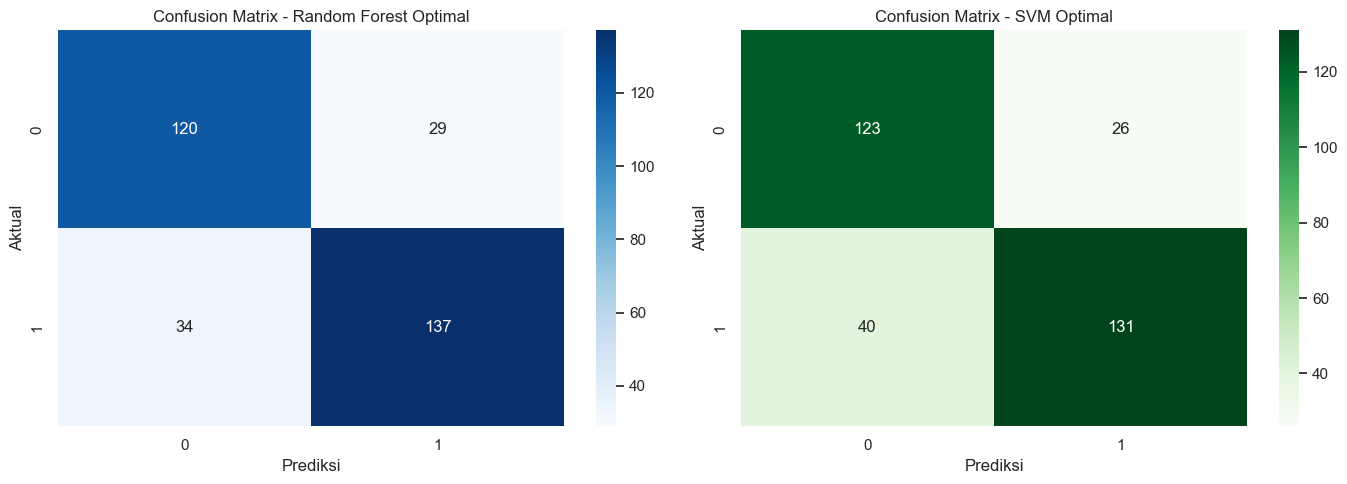

In [8]:
# Visualisasi Confusion Matrix
y_pred_rf = best_rf_model.predict(X_test)
y_pred_svm = best_svm_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix - Random Forest Optimal")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Confusion Matrix - SVM Optimal")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

plt.tight_layout()
plt.show()


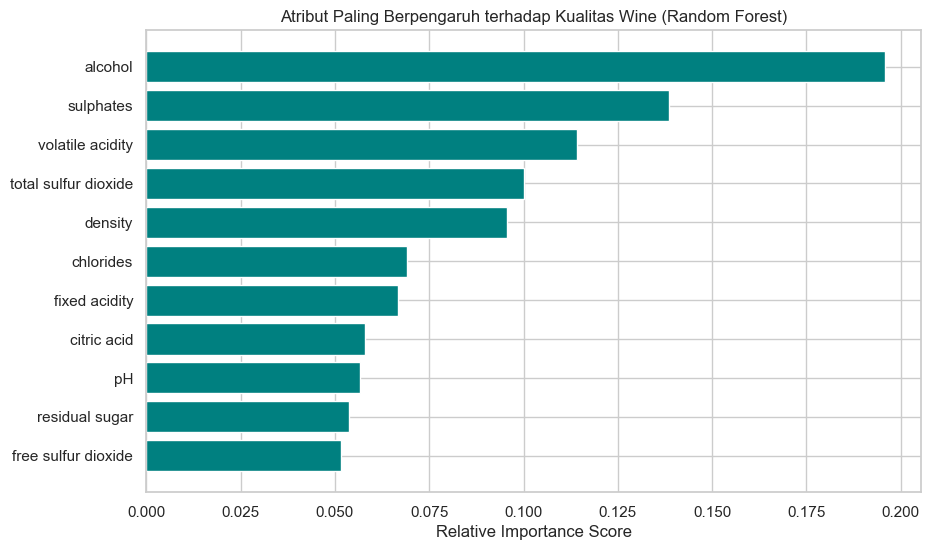

In [9]:
# Feature Importance Random Forest
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Atribut Paling Berpengaruh terhadap Kualitas Wine (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Importance Score")
plt.show()
